In [4]:
import sys
!{sys.executable} -m pip install openpyxl scipy matplotlib numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
print("hola")

hola


In [6]:
import openpyxl

def leer_excel(archivo):
    """Lee un Excel de resultados y devuelve un dict por instancia."""
    wb = openpyxl.load_workbook(archivo)
    datos = {}

    for hoja in wb.sheetnames:
        if hoja == "Resumen":
            continue

        ws = wb[hoja]

        # encontrar columnas FO_final y Tiempo_s por su encabezado
        encabezados = [c.value for c in ws[1]]
        col_fo     = encabezados.index("FO_final") + 1
        col_tiempo = encabezados.index("Tiempo_s") + 1
        n_iter     = encabezados.index("FO_final") - 1  # iteraciones antes de FO_final

        resultados = []
        tiempos = []
        historiales = []

        fila = 2
        while ws.cell(row=fila, column=1).value is not None:
            resultados.append(ws.cell(row=fila, column=col_fo).value)
            tiempos.append(ws.cell(row=fila, column=col_tiempo).value)
            # historial = columnas 2 hasta n_iter+1
            hist = [ws.cell(row=fila, column=2 + it).value for it in range(n_iter)]
            historiales.append(hist)
            fila += 1

        datos[hoja] = {
            "resultados": resultados,
            "tiempos": tiempos,
            "historiales": historiales
        }

    return datos

coa = leer_excel("resultados_COA.xlsx")
pso = leer_excel("resultados_PSO.xlsx")

print("Instancias COA:", list(coa.keys()))
print("Instancias PSO:", list(pso.keys()))
print("Corridas COA Small:", len(coa["Small"]["resultados"]))

Instancias COA: ['Small', 'Medium', 'Big']
Instancias PSO: ['Small', 'Medium', 'Big']
Corridas COA Small: 40


In [8]:
from scipy.stats import wilcoxon

def comparar_wilcoxon(coa, pso):
    print("=" * 70)
    print("TEST DE WILCOXON — COA vs PSO")
    print("=" * 70)
    print("H0: no hay diferencia significativa entre COA y PSO")
    print("Si p-value < 0.05 -> la diferencia ES significativa\n")

    for instancia in coa.keys():
        res_coa = coa[instancia]["resultados"]
        res_pso = pso[instancia]["resultados"]

        prom_coa = sum(res_coa) / len(res_coa)
        prom_pso = sum(res_pso) / len(res_pso)

        print("-" * 70)
        print(f"Instancia: {instancia}")
        print(f"  Promedio COA: {round(prom_coa, 2)}")
        print(f"  Promedio PSO: {round(prom_pso, 2)}")

        # Si todos los valores son idénticos (ej. Small siempre 76.9),
        # Wilcoxon no se puede calcular
        diferencias = [a - b for a, b in zip(res_coa, res_pso)]
        if all(d == 0 for d in diferencias):
            print("  Wilcoxon: no aplicable (resultados idénticos)")
            continue

        stat, p_value = wilcoxon(res_coa, res_pso)
        print(f"  Estadístico W: {round(stat, 4)}")
        print(f"  p-value: {p_value:.2e}")   # notación científica

        if p_value < 0.05:
            mejor = "COA" if prom_coa < prom_pso else "PSO"
            print(f"  -> Diferencia SIGNIFICATIVA. Mejor algoritmo: {mejor}")
        else:
            print(f"  -> Diferencia NO significativa (estadísticamente equivalentes)")

comparar_wilcoxon(coa, pso)

TEST DE WILCOXON — COA vs PSO
H0: no hay diferencia significativa entre COA y PSO
Si p-value < 0.05 -> la diferencia ES significativa

----------------------------------------------------------------------
Instancia: Small
  Promedio COA: 76.9
  Promedio PSO: 76.9
  Wilcoxon: no aplicable (resultados idénticos)
----------------------------------------------------------------------
Instancia: Medium
  Promedio COA: 930.74
  Promedio PSO: 920.08
  Estadístico W: 96.0
  p-value: 2.44e-05
  -> Diferencia SIGNIFICATIVA. Mejor algoritmo: PSO
----------------------------------------------------------------------
Instancia: Big
  Promedio COA: 1921.42
  Promedio PSO: 1875.59
  Estadístico W: 0.0
  p-value: 1.82e-12
  -> Diferencia SIGNIFICATIVA. Mejor algoritmo: PSO


C:\Users\migue\AppData\Local\Temp\ipykernel_9768\4084459286.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos, labels=["COA", "PSO"], showmeans=True)


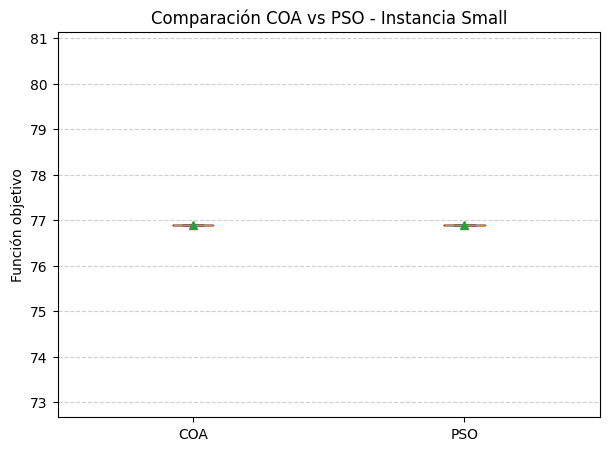

C:\Users\migue\AppData\Local\Temp\ipykernel_9768\4084459286.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos, labels=["COA", "PSO"], showmeans=True)


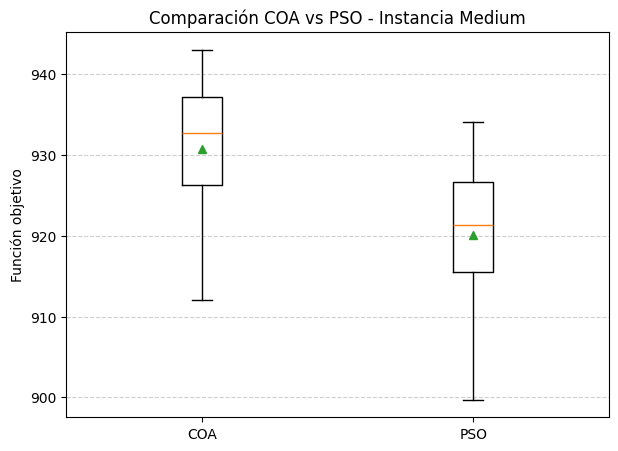

C:\Users\migue\AppData\Local\Temp\ipykernel_9768\4084459286.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos, labels=["COA", "PSO"], showmeans=True)


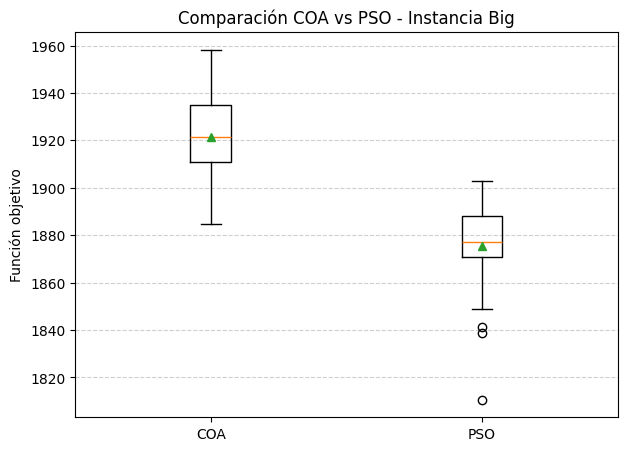

In [9]:
import matplotlib.pyplot as plt

def boxplot_comparativo(coa, pso):
    for instancia in coa.keys():
        plt.figure(figsize=(7, 5))
        datos = [coa[instancia]["resultados"], pso[instancia]["resultados"]]
        plt.boxplot(datos, labels=["COA", "PSO"], showmeans=True)

        plt.title(f"Comparación COA vs PSO - Instancia {instancia}")
        plt.ylabel("Función objetivo")
        plt.grid(axis="y", linestyle="--", alpha=0.6)
        plt.show()

boxplot_comparativo(coa, pso)

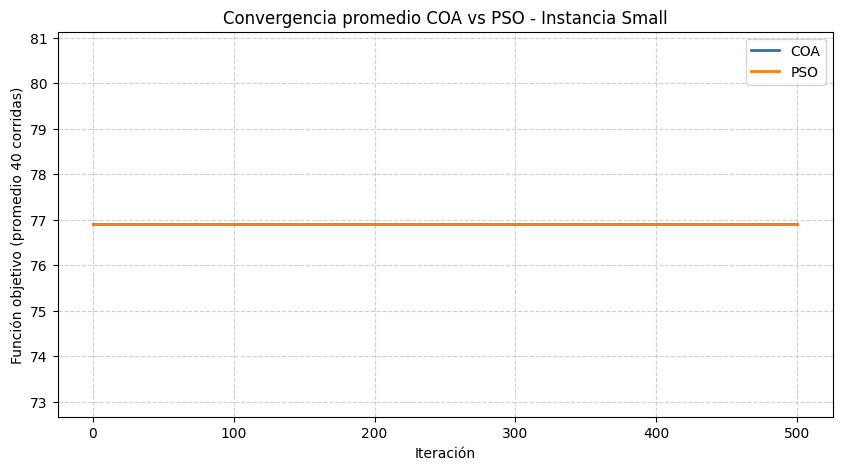

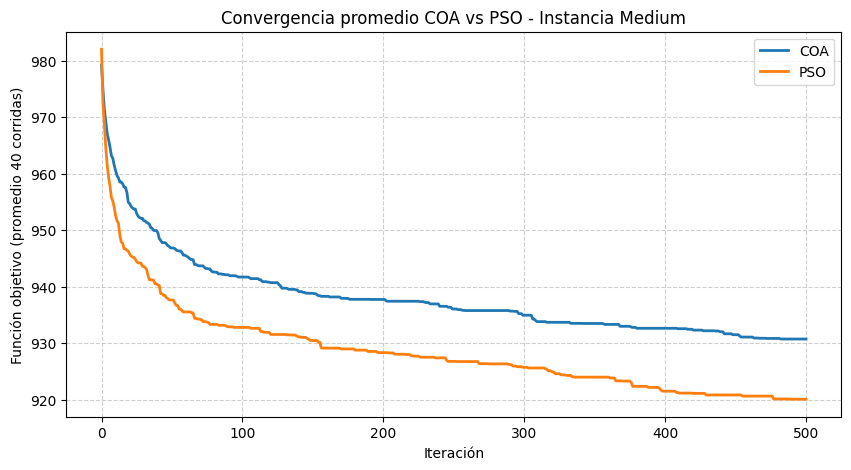

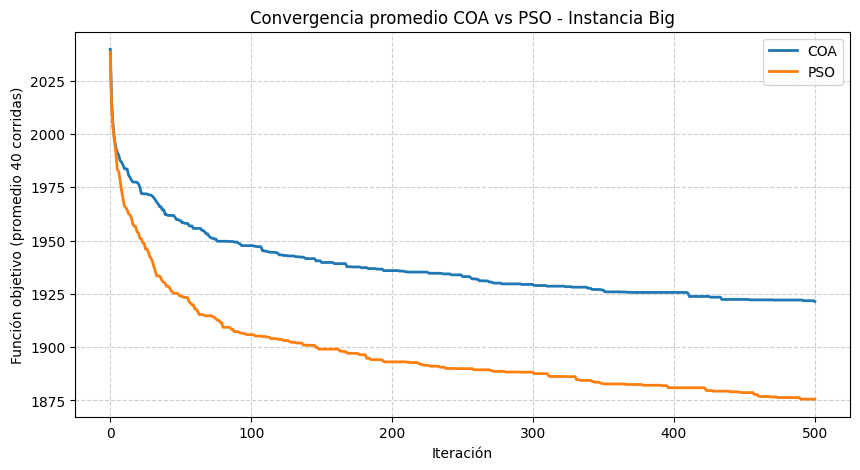

In [10]:
import numpy as np

def convergencia_comparativa(coa, pso):
    for instancia in coa.keys():
        hist_coa = np.array(coa[instancia]["historiales"]).mean(axis=0)
        hist_pso = np.array(pso[instancia]["historiales"]).mean(axis=0)

        plt.figure(figsize=(10, 5))
        plt.plot(hist_coa, label="COA", linewidth=2)
        plt.plot(hist_pso, label="PSO", linewidth=2)

        plt.title(f"Convergencia promedio COA vs PSO - Instancia {instancia}")
        plt.xlabel("Iteración")
        plt.ylabel("Función objetivo (promedio 40 corridas)")
        plt.legend()
        plt.grid(linestyle="--", alpha=0.6)
        plt.show()

convergencia_comparativa(coa, pso)